<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Epoch   1/100 | LR: 6.78e-05 | train loss 0.8755 acc 0.685 | val loss 0.5978 acc 0.744 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 6.78e-05 | train loss 0.6679 acc 0.738 | val loss 0.6740 acc 0.653


[ConvNeXt-Tiny] Epoch   3/100 | LR: 6.78e-05 | train loss 0.5732 acc 0.792 | val loss 0.6000 acc 0.722


[ConvNeXt-Tiny] Epoch   4/100 | LR: 6.78e-05 | train loss 0.5204 acc 0.802 | val loss 0.4781 acc 0.781 *


[ConvNeXt-Tiny] Epoch   5/100 | LR: 6.78e-05 | train loss 0.4545 acc 0.815 | val loss 0.4600 acc 0.791 *


...

[ConvNeXt-Tiny] Epoch  20/100 | LR: 6.78e-05 | train loss 0.1352 acc 0.953 | val loss 0.4368 acc 0.847


[ConvNeXt-Tiny] Epoch  21/100 | LR: 6.78e-05 | train loss 0.0627 acc 0.982 | val loss 0.5766 acc 0.825


[ConvNeXt-Tiny] Epoch  22/100 | LR: 6.78e-05 | train loss 0.0926 acc 0.973 | val loss 0.3892 acc 0.881


[ConvNeXt-Tiny] Epoch  23/100 | LR: 6.78e-05 | train loss 0.0823 acc 0.973 | val loss 0.4630 acc 0.863


[ConvNeXt-Tiny] Epoch  24/100 | LR: 6.78e-05 | train loss 0.1472 acc 0.955 | val loss 0.4533 acc 0.847

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 24.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3693)


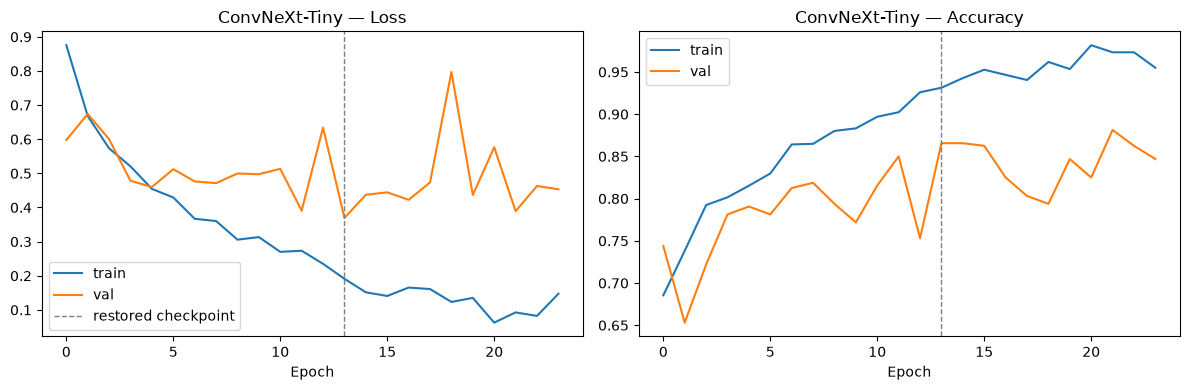

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.558


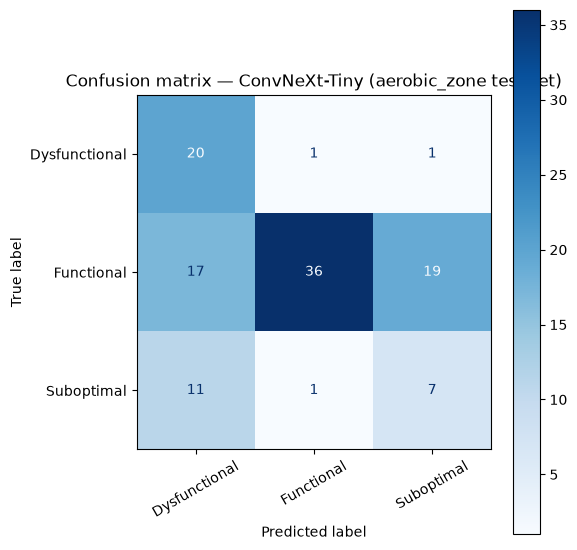

               precision    recall  f1-score   support

Dysfunctional      0.417     0.909     0.571        22
   Functional      0.947     0.500     0.655        72
   Suboptimal      0.259     0.368     0.304        19

     accuracy                          0.558       113
    macro avg      0.541     0.593     0.510       113
 weighted avg      0.728     0.558     0.579       113



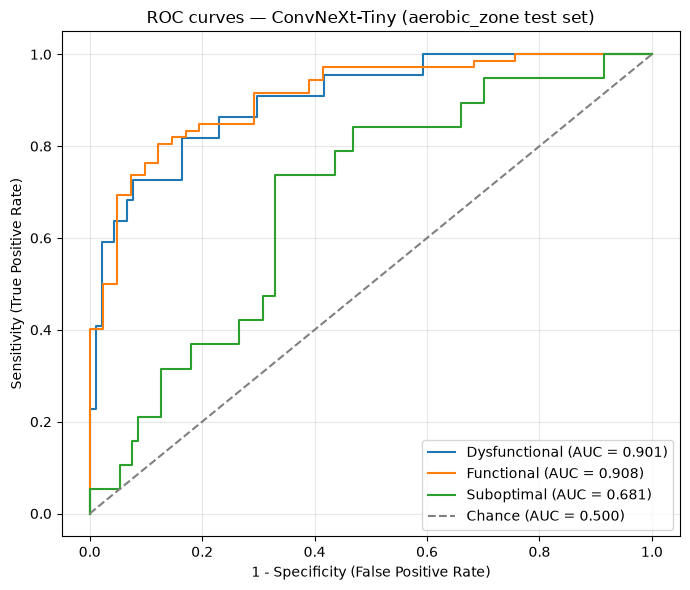

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.901
  Functional     : 0.908
  Suboptimal     : 0.681

Mean AUC (over 3/3 classes with test examples): 0.830


(np.float64(0.5575221238938053),
 {'Dysfunctional': 0.9005994005994006,
  'Functional': 0.9075203252032521,
  'Suboptimal': 0.6814109742441209})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_convnext_tiny_Atlantis.pkl
Saved model weights to ../models/aerobic_zone_convnext_tiny_cnn.pt
